# Code for Ch 2: Quantum Algorithms
This Jupyter notebook contains Qiskit code used for Chapter 2 of my tutorial on Quantum Machine Learning (QML), which is based on material from the 2021 Qiskit Summer School on QML and the online Qiskit textbook.

NB: it's worth noting, that the code here has been created with LLM assistance and by referring to the online Qiskit textbook

In [133]:
# Boilerplate to run 
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
import matplotlib.patches as patches
plt.style.use('intro_to_qml_figure_style.mpltstyle') # This style sheet is in use.
 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)

from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display
import numpy as np

figure_directory = 'Figures/Ch2_Quantum_Algorithms_Figures/'

# Simple Demonstration of Quantum Effects
## Quantum Teleportation

The Qiskit implementation here and for superdense encording is based on implementations from the following <a href="https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation">Qiskit learning material</a>.

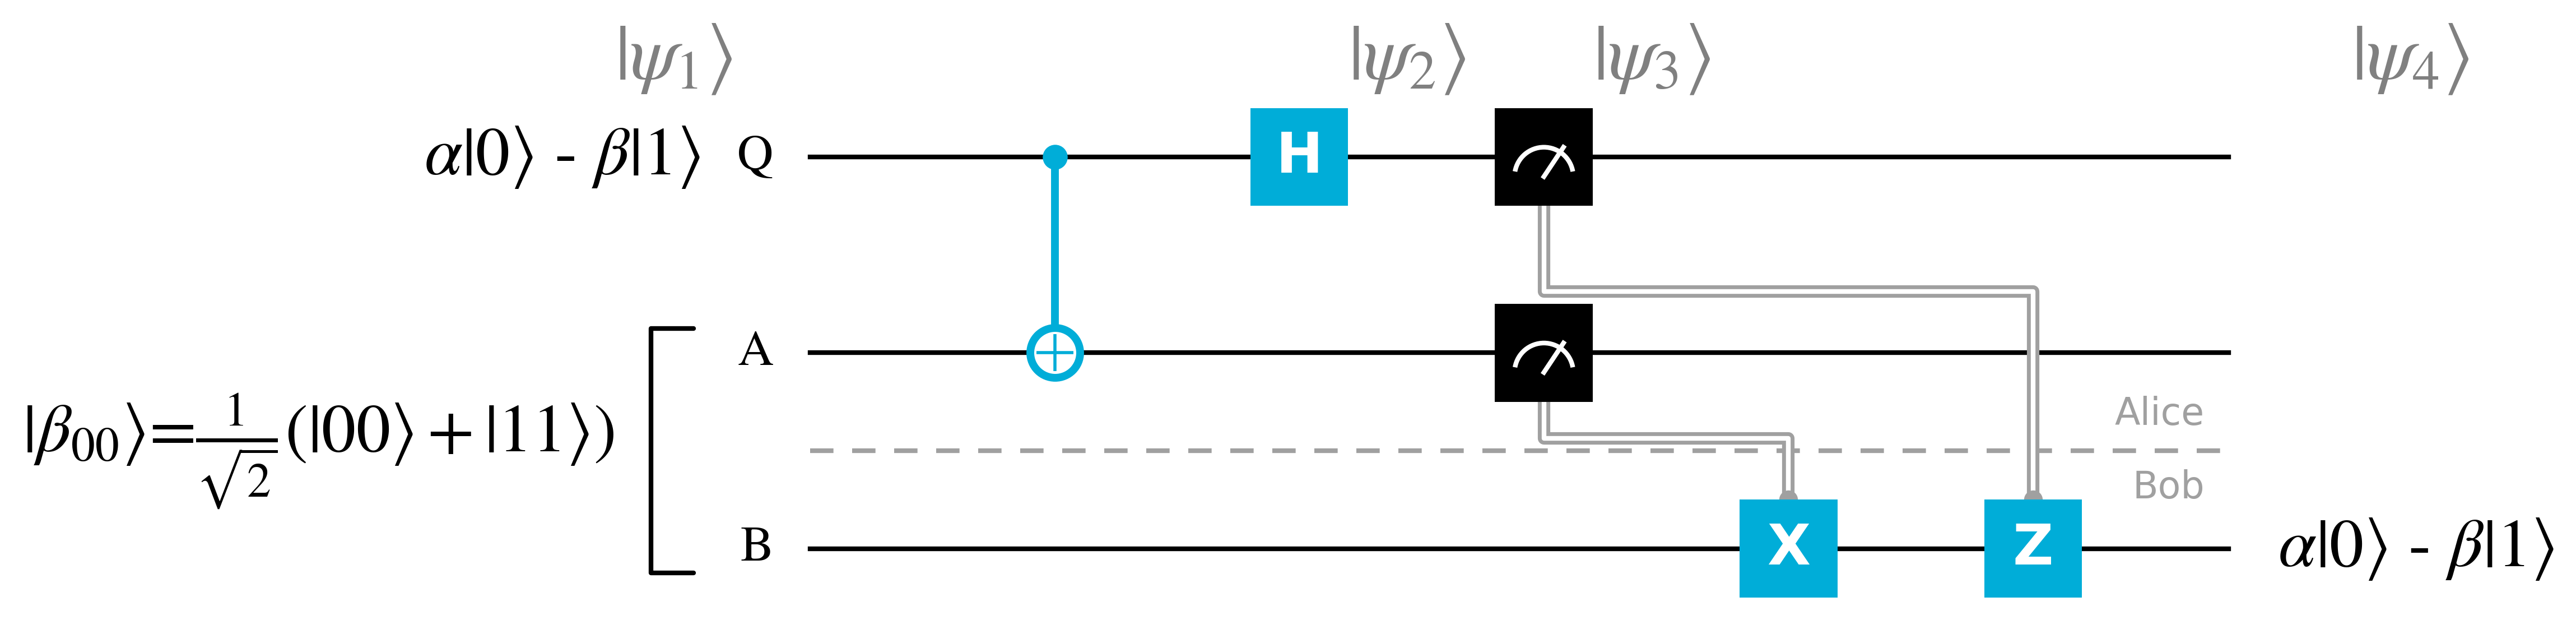

In [93]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Force Matplotlib to use STIX for all math text natively
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_teleportation_mpl(filename):
    # Set high resolution and canvas size
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=400)
    ax.set_xlim(40, 750)
    ax.set_ylim(280, 60) # Inverted Y-axis so y=100 is at the top
    ax.axis('off') # Hide axes
    
    # === ADD THIS LINE TO FIX THE STRETCHING ===
    ax.set_aspect('equal') # Forces perfect square units
    # ============================================

    # --- Constants & Layout ---
    WIRE_Q, WIRE_A, WIRE_B = 100, 180, 260
    START_X, END_X = 120, 700
    BLUE = '#00ADD8'  # Rich cyan/blue matching the previous image
    BLACK = 'black'
    GREY = '#A0A0A0'

    # ==========================================
    # 2. DRAW WIRES & DIVIDER
    # ==========================================
    for y in [WIRE_Q, WIRE_A, WIRE_B]:
        ax.plot([START_X, END_X], [y, y], color=BLACK, lw=1.5, zorder=1)

    # Dashed dividing line
    ax.plot([START_X, END_X], [220, 220], color=GREY, lw=1.5, linestyle='--', dashes=(5, 4), zorder=1)
    ax.text(END_X - 10, 205, "Alice", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')
    ax.text(END_X - 10, 235, "Bob", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')

    # ==========================================
    # 3. LABELS & KETS (Full LaTeX Support!)
    # ==========================================
    text_opts = {'fontsize': 16, 'va': 'center'}
    ax.text(START_X - 15, WIRE_Q, "Q", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_A, "A", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_B, "B", ha='right', **text_opts)

    # Because of Matplotlib, we can use pure LaTeX strings now!
    ax.text(START_X - 45, WIRE_Q, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='right', fontsize=22, va='center')
    ax.text(START_X - 80, (WIRE_A + WIRE_B)/2, r"$|\beta_{00}\rangle$=$\frac{1}{\sqrt{2}}(|00\rangle +|11\rangle)$", ha='right', fontsize=22, va='center')
    ax.text(END_X + 20, WIRE_B, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='left', fontsize=22, va='center')

    # Draw curly bracket using Matplotlib annotations
    ax.annotate('', xy=(START_X - 45, WIRE_A - 10), xytext=(START_X - 45, WIRE_B + 10),
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,fraction=-0.2', lw=1.5))

    # ==========================================
    # 4. HELPER FUNCTIONS FOR GATES
    # ==========================================
    def draw_gate(x, y, text):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=18, fontweight='bold', ha='center', va='center', zorder=4, fontfamily='sans-serif')

    def draw_meter(x, y):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y+8), 24, 24, theta1=190, theta2=350, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x+8], [y+8, y-4], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 5. GATES & MEASUREMENTS
    # ==========================================
    # CNOT
    cnot_x = 220
    ax.plot([cnot_x, cnot_x], [WIRE_Q, WIRE_A], color=BLUE, lw=2.5, zorder=2)
    ax.plot(cnot_x, WIRE_Q, marker='o', color=BLUE, markersize=7, zorder=3) # Control
    ax.plot(cnot_x, WIRE_A, marker='o', color='white', markeredgecolor=BLUE, markeredgewidth=2.5, markersize=16, zorder=3) # Target
    ax.plot(cnot_x, WIRE_A, marker='+', color=BLUE, markersize=12, zorder=4) # Cross

    draw_gate(320, WIRE_Q, "H")
    meter_x = 420
    draw_meter(meter_x, WIRE_Q)
    draw_meter(meter_x, WIRE_A)

    # ==========================================
    # 6. CLASSICAL COMMUNICATION LINES
    # ==========================================
    gate_x_pos, gate_z_pos = 520, 620

    # Lower line (A to X)
    x_lower = [meter_x, meter_x, gate_x_pos, gate_x_pos]
    y_lower = [WIRE_A + 20, WIRE_A + 35, WIRE_A + 35, WIRE_B - 20]
    ax.plot(x_lower, y_lower, color=GREY, lw=4, zorder=1)
    ax.plot(x_lower, y_lower, color='white', lw=1.5, zorder=2) # Creates the "double line" look

    # Upper line (Q to Z)
    x_upper = [meter_x, meter_x, gate_z_pos, gate_z_pos]
    y_upper = [WIRE_Q + 20, WIRE_A - 25, WIRE_A - 25, WIRE_B - 20]
    ax.plot(x_upper, y_upper, color=GREY, lw=4, zorder=1)
    ax.plot(x_upper, y_upper, color='white', lw=1.5, zorder=2)

    # Connection dots on classical wires
    ax.plot([gate_x_pos, gate_z_pos], [WIRE_B - 20, WIRE_B - 20], marker='o', color=GREY, markersize=5, lw=0, zorder=3)

    # Conditional Gates
    draw_gate(gate_x_pos, WIRE_B, "X")
    draw_gate(gate_z_pos, WIRE_B, "Z")

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
  
    ax.text(x_min + 0, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
    ax.text(x_min + 300, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
    ax.text(x_min + 400, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
    ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)

    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    #print(f"Success! Perfect LaTeX diagram saved to {filename}")

draw_teleportation_mpl(figure_directory+'quantum_teleportation_sketch.png')

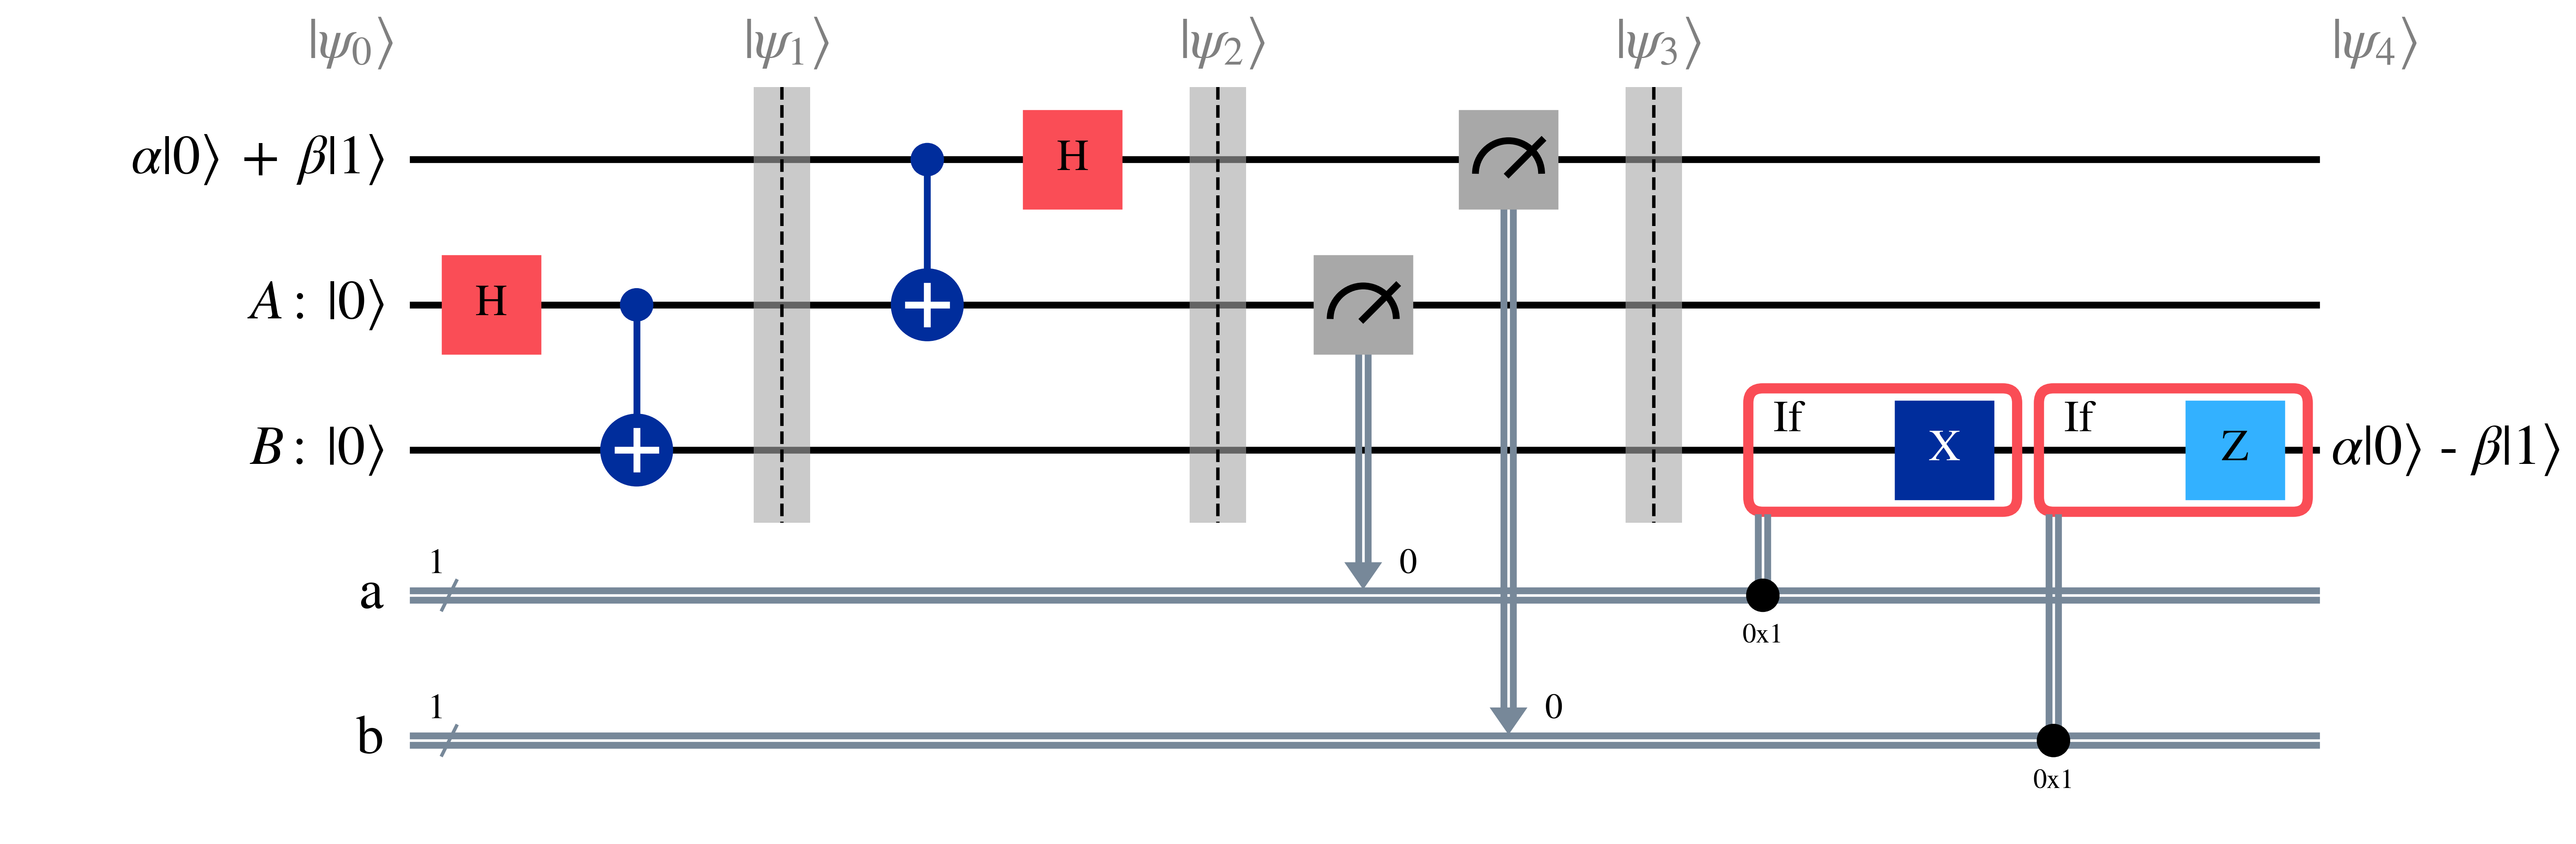

In [94]:
# Note, the folowing is based on code from https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation
qubit = QuantumRegister(1, "α|0⟩ + β|1⟩")
ebit0 = QuantumRegister(1, "A: |0⟩")
ebit1 = QuantumRegister(1, "B: |0⟩")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

#display(protocol.draw(output="mpl"))

fig_qc = protocol.draw(output='mpl', scale =1.5)#, initial_state=False)
ax = fig_qc.axes[0]
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.set_xlim(x_min, x_max + 1.5)
ax.set_ylim(y_min , y_max + 0.1)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_min+2, y_max , r'$|\psi_0\rangle$', color='gray', **font_style)
ax.text(x_min + 5, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
ax.text(x_min + 8, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
ax.text(x_min + 11, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)
ax.text(x_max, y_min+2.6, r"$\alpha|0\rangle$ - $\beta|1\rangle$", **font_style)

fig_qc.savefig(figure_directory+'quantum_teleportation_annotated_circuit.png', bbox_inches='tight')

## Superdense encoding

The Qiskit implementation here and for quantum teleportation is based on implementations from the following <a href="https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation">Qiskit learning material</a>.

Success! Diagram saved to Figures/Ch2_Quantum_Algorithms_Figures/superdense_coding_sketch.png


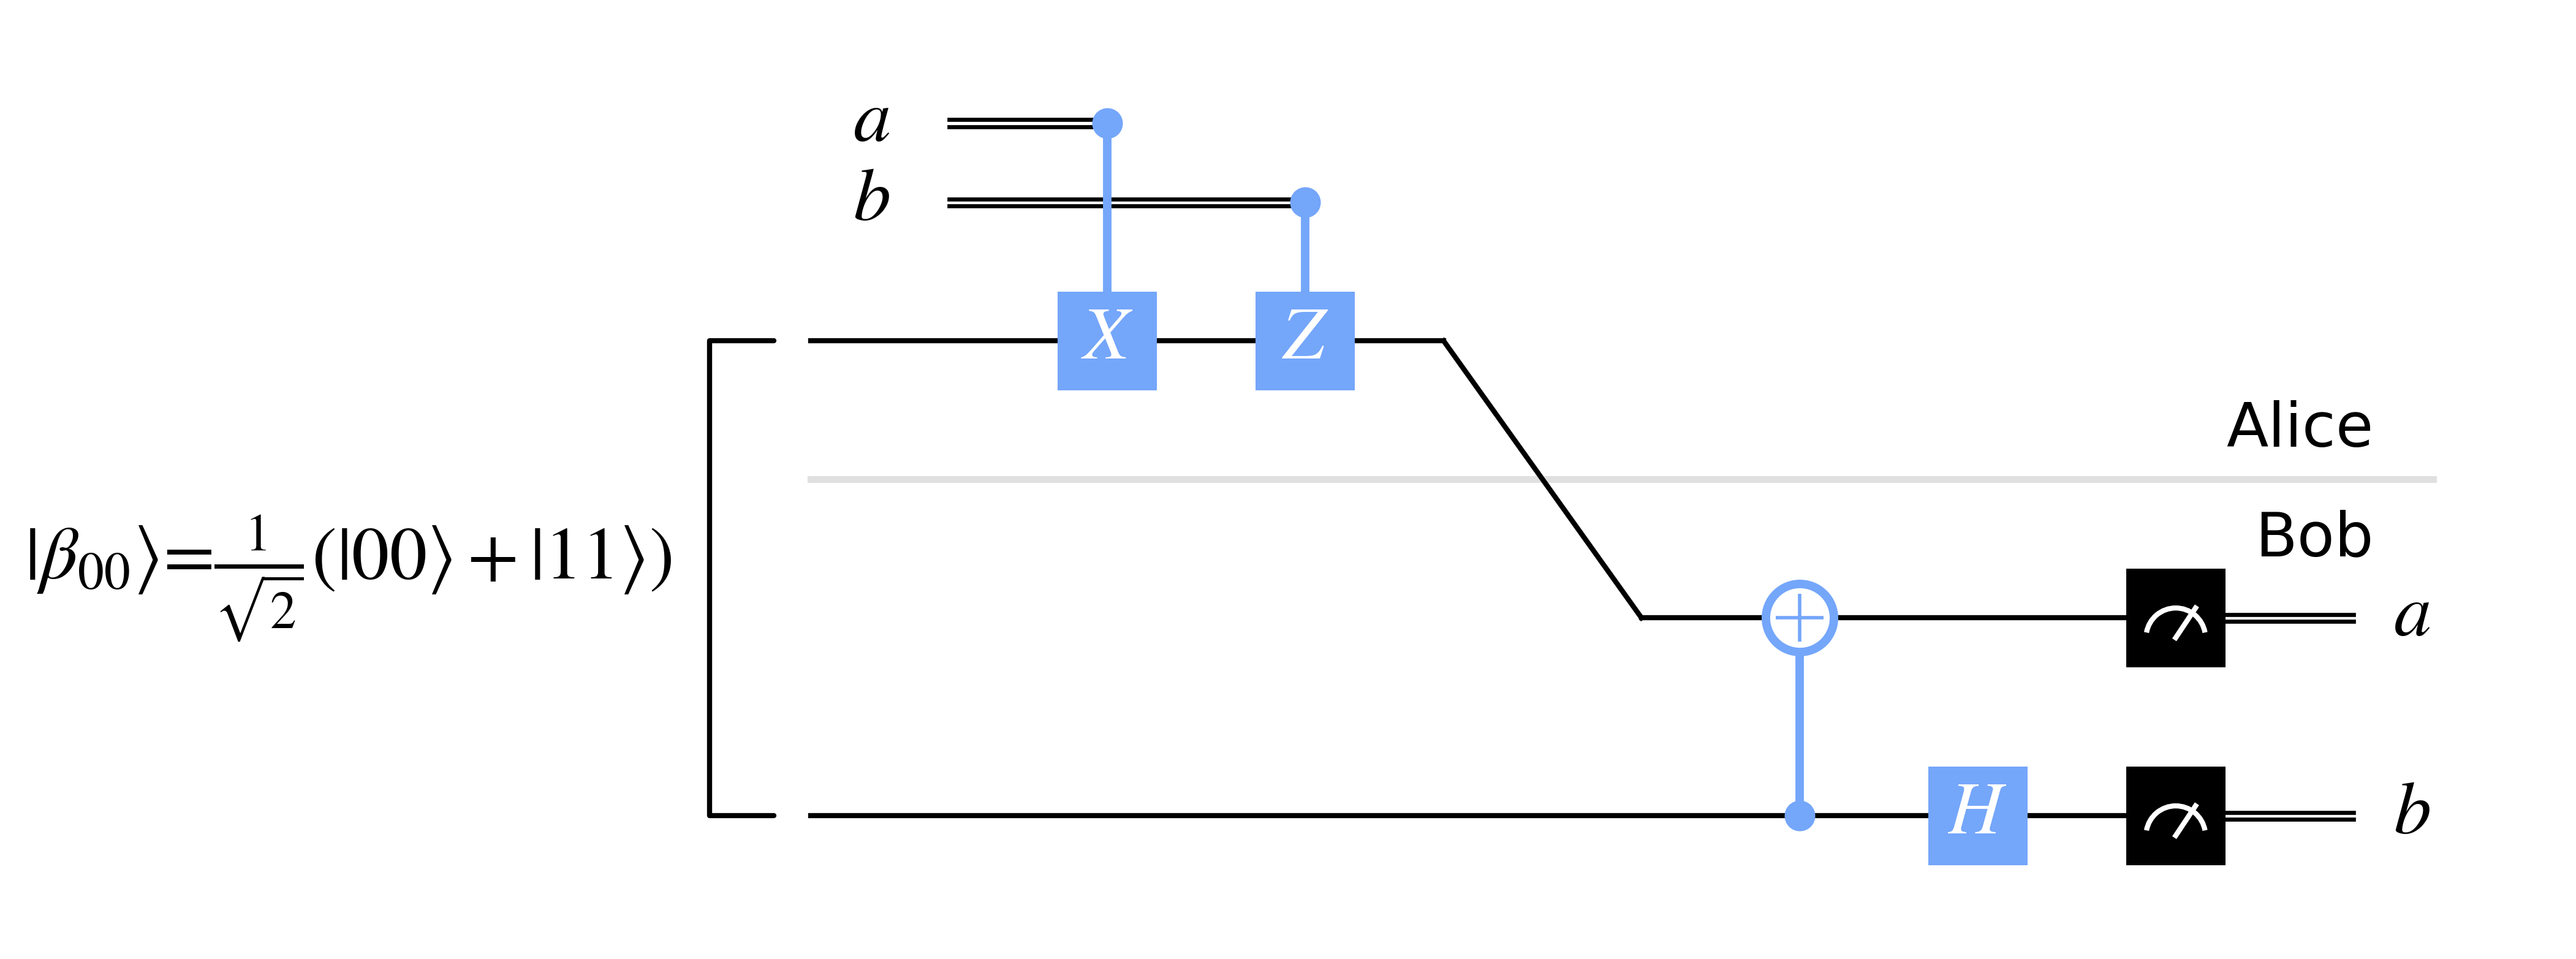

In [95]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Force Matplotlib to use STIX for all math text natively
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_superdense_mpl(filename):
    # Set high resolution and canvas size
    fig, ax = plt.subplots(figsize=(10, 6), dpi=400)
    ax.set_xlim(20, 980)
    ax.set_ylim(480, 20) # Inverted Y-axis so y=0 is at the top
    ax.axis('off') # Hide axes
    
    # Force perfect square units to prevent gate stretching
    ax.set_aspect('equal') 

    # --- Constants & Colors ---
    BLUE = '#74A6FA'  # Soft cornflower blue from the image
    BLACK = 'black'
    GREY = '#E0E0E0'  # Light grey for the divider

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def double_line(x0, x1, y, color=BLACK, lw=1.2, gap=4):
        """Draws the double lines used for classical bits."""
        ax.plot([x0, x1], [y - gap/2, y - gap/2], color=color, lw=lw, zorder=1)
        ax.plot([x0, x1], [y + gap/2, y + gap/2], color=color, lw=lw, zorder=1)

    def draw_gate(x, y, text):
        rect = patches.Rectangle((x-25, y-25), 50, 50, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, f"${text}$", color='white', fontsize=22, ha='center', va='center', zorder=4)

    def draw_meter(x, y):
        rect = patches.Rectangle((x-25, y-25), 50, 50, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y+10), 30, 30, theta1=190, theta2=350, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x+10], [y+10, y-5], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 1. DIVIDER & LABELS (Alice / Bob)
    # ==========================================
    ax.plot([100, 920], [250, 250], color=GREY, lw=2, zorder=1)
    ax.text(890, 225, "Alice", color=BLACK, fontsize=18, ha='right', va='center', fontfamily='sans-serif')
    ax.text(890, 280, "Bob", color=BLACK, fontsize=18, ha='right', va='center', fontfamily='sans-serif')

    # ==========================================
    # 2. LEFT SIDE WIRES & INITIAL STATES
    # ==========================================
    # Initial Qubit wires
    ax.plot([100, 420], [180, 180], color=BLACK, lw=1.5, zorder=1) # Alice's half of the Bell pair
    ax.plot([100, 800], [420, 420], color=BLACK, lw=1.5, zorder=1) # Bob's half of the Bell pair

    # Initial State Bracket & Label
    ax.text(30, 300, r"$|\beta_{00}\rangle$=$\frac{1}{\sqrt{2}}(|00\rangle +|11\rangle)$", ha='right', fontsize=22, va='center')
    ax.annotate('', xy=(85, 180), xytext=(85, 420),
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,fraction=-0.15', lw=1.5))

    # Classical Inputs at the top left
    double_line(170, 250, 70, gap=3.5) # d wire
    double_line(170, 350, 110, gap=3.5) # c wire
    ax.text(140, 70, "$a$", fontsize=22, ha='right', va='center')
    ax.text(140, 110, "$b$", fontsize=22, ha='right', va='center')

    # ==========================================
    # 3. ALICE'S ENCODING GATES
    # ==========================================
    # Z gate controlled by classical wire d
    ax.plot([250, 250], [70, 180], color=BLUE, lw=2.5, zorder=2)
    ax.plot(250, 70, marker='o', color=BLUE, markersize=8, zorder=3) # Control dot
    draw_gate(250, 180, "X")

    # X gate controlled by classical wire c
    ax.plot([350, 350], [110, 180], color=BLUE, lw=2.5, zorder=2)
    ax.plot(350, 110, marker='o', color=BLUE, markersize=8, zorder=3) # Control dot
    draw_gate(350, 180, "Z")

    # ==========================================
    # 4. TRANSMISSION SLANT (Alice sends to Bob)
    # ==========================================
    ax.plot([420, 520], [180, 320], color=BLACK, lw=1.5, zorder=1)
    ax.plot([520, 800], [320, 320], color=BLACK, lw=1.5, zorder=1) # Received wire continues

    # ==========================================
    # 5. BOB'S DECODING GATES
    # ==========================================
    # CNOT
    cnot_x = 600
    ax.plot([cnot_x, cnot_x], [320, 420], color=BLUE, lw=2.5, zorder=2)
    ax.plot(cnot_x, 420, marker='o', color=BLUE, markersize=8, zorder=3) # Control
    ax.plot(cnot_x, 320, marker='o', color='white', markeredgecolor=BLUE, markeredgewidth=2.5, markersize=20, zorder=3) # Target Circle
    ax.plot(cnot_x, 320, marker='+', color=BLUE, markersize=14, zorder=4) # Target Cross

    # H Gate
    draw_gate(690, 420, "H")

    # ==========================================
    # 6. MEASUREMENTS & OUTPUTS
    # ==========================================
    draw_meter(790, 320)
    draw_meter(790, 420)

    # Output classical wires
    double_line(815, 880, 320, gap=3.5)
    double_line(815, 880, 420, gap=3.5)
    
    # Output labels
    ax.text(900, 320, "$a$", fontsize=22, ha='left', va='center')
    ax.text(900, 420, "$b$", fontsize=22, ha='left', va='center')

    # Save the result
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Diagram saved to {filename}")

# Execute the drawing function
draw_superdense_mpl(figure_directory+'superdense_coding_sketch.png')

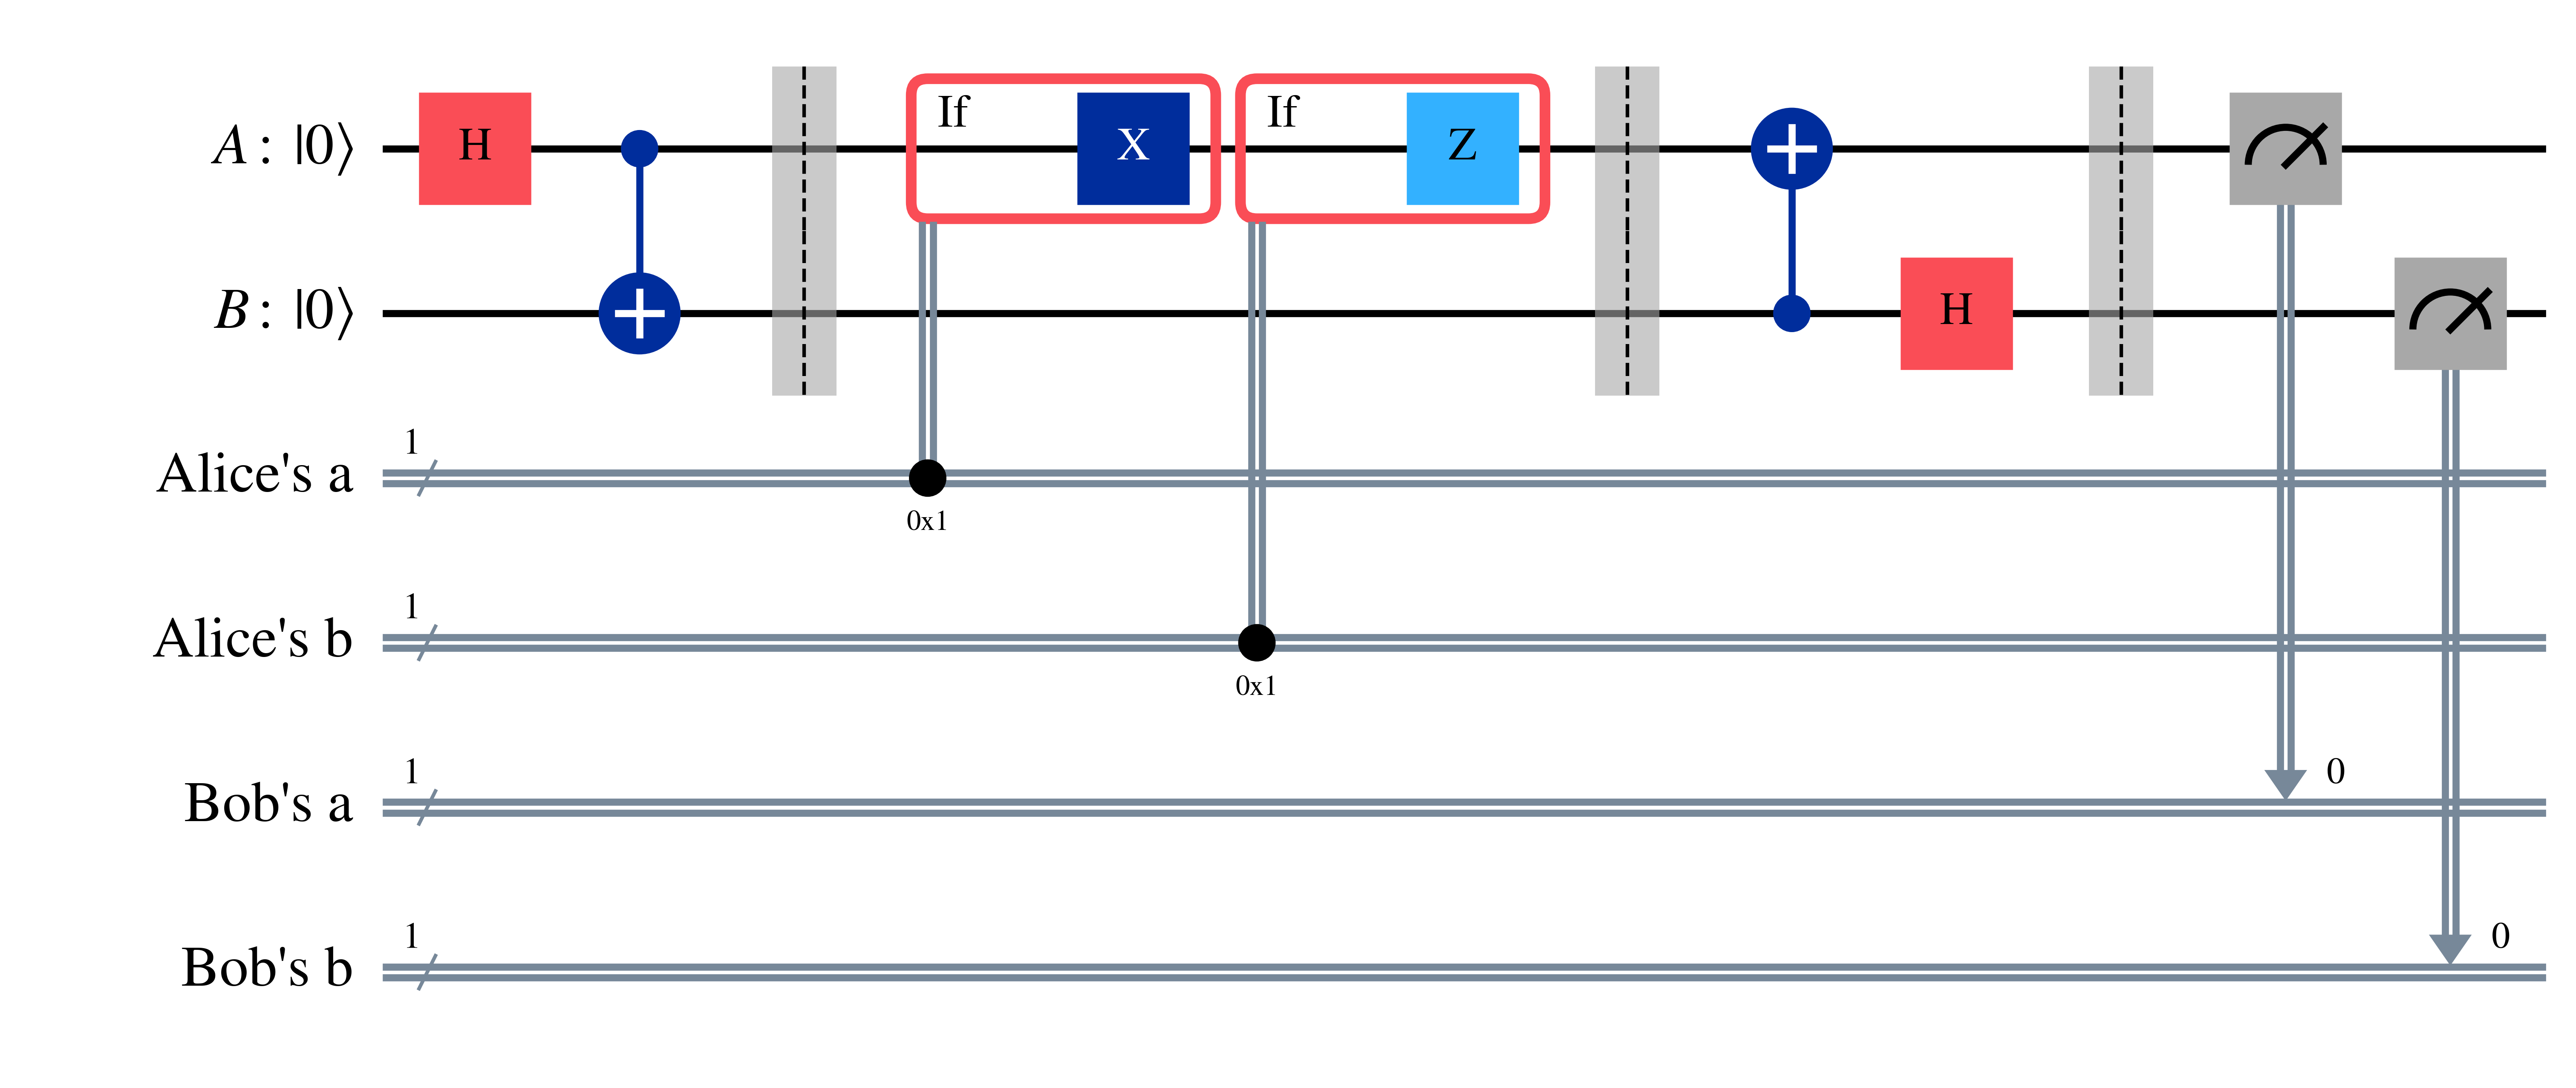

In [97]:
# Note, the folowing is based on code from https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation
a = ClassicalRegister(1, "Alice's a")
b = ClassicalRegister(1, "Alice's b")
ebit0 = QuantumRegister(1, "A: |0⟩")
ebit1 = QuantumRegister(1, "B: |0⟩")
a_1 = ClassicalRegister(1, "Bob's a")
b_1 = ClassicalRegister(1, "Bob's b")

protocol = QuantumCircuit(a, b, ebit0, ebit1, a_1, b_1)

# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Alice's operations
# if d == "1":
#     protocol.z(0)
# if c == "1":
#     protocol.x(0)
with protocol.if_test((a, 1)):
    protocol.x(ebit0)
with protocol.if_test((b, 1)):
    protocol.z(ebit0)
protocol.barrier()

# Bob's actions
protocol.cx(1, 0)
protocol.h(1)
protocol.barrier()
protocol.measure(ebit0, a_1)
protocol.measure(ebit1, b_1)

fig_qc = protocol.draw(output='mpl', scale =1.5)
fig_qc.savefig(figure_directory+'superdense_coding_annotated_circuit.png', bbox_inches='tight')


## Quantum Parallelism

The figures here are based on https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa

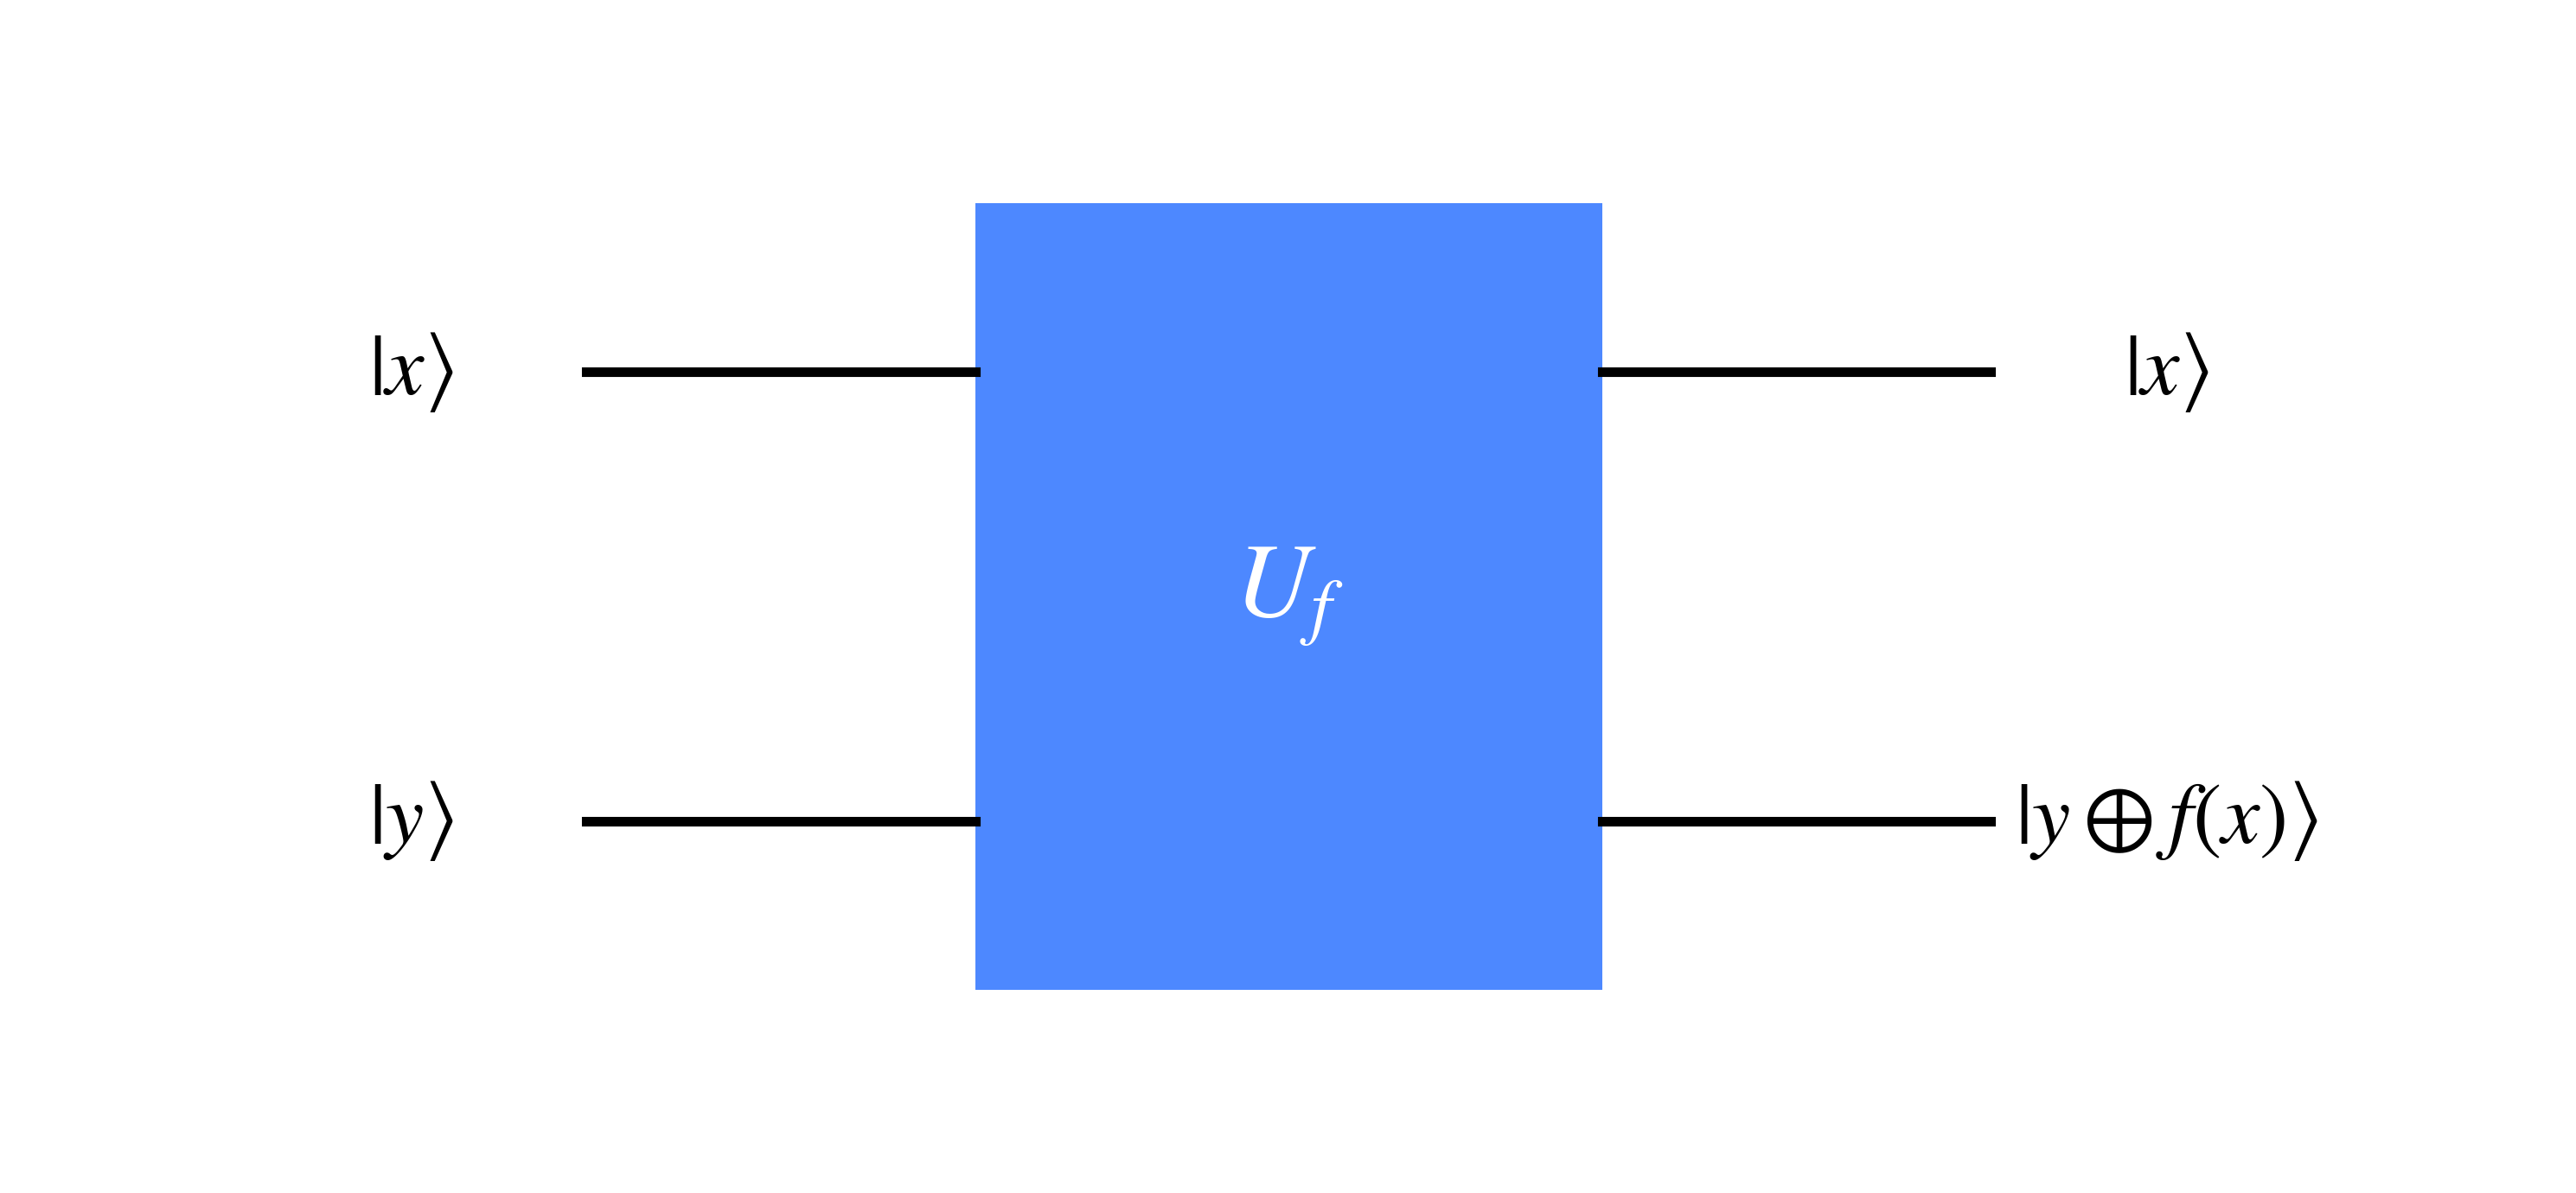

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set figure size for good aspect ratio and resolution
fig_width_inch = 8
fig_height_inch = 4

# Create figure and axis
fig, ax = plt.subplots(figsize=(fig_width_inch, fig_height_inch))

# Set axis limits to [0, 1] scale for clean coordinates
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Hide axis spines, ticks, and labels to create a clean canvas
ax.axis('off')

# Set figure facecolor to white to match the input image background
fig.patch.set_facecolor('white')

# Define coordinate constants for elements
left_text_x = 0.15
left_line_start_x = 0.22
rect_start_x = 0.375
rect_width = 0.25
rect_center_x = 0.5
rect_end_x = 0.625
right_line_end_x = 0.78
right_text_x = 0.85

top_qubit_y = 0.7
bottom_qubit_y = 0.3
rect_start_y = 0.15
rect_height = 0.7
rect_center_y = 0.5

# Standard font size for diagram labels
font_size = 18

# Line thickness for qubit wires
line_thickness = 2.0

# Qubit lines (left side)
ax.plot([left_line_start_x, rect_start_x], [top_qubit_y, top_qubit_y], color='black', linewidth=line_thickness)
ax.plot([left_line_start_x, rect_start_x], [bottom_qubit_y, bottom_qubit_y], color='black', linewidth=line_thickness)

# Qubit lines (right side)
ax.plot([rect_end_x, right_line_end_x], [top_qubit_y, top_qubit_y], color='black', linewidth=line_thickness)
ax.plot([rect_end_x, right_line_end_x], [bottom_qubit_y, bottom_qubit_y], color='black', linewidth=line_thickness)

# Oracle block (blue rectangle)
# Pick a flat blue color similar to the original image.
# An RGB color is used for precision.
oracle_blue = (77/255, 136/255, 255/255)
oracle_block = patches.Rectangle((rect_start_x, rect_start_y), rect_width, rect_height, facecolor=oracle_blue, edgecolor='none')
ax.add_patch(oracle_block)

# Input text labels (left side)
# Use math font style for quantum states with bra-ket notation
ax.text(left_text_x, top_qubit_y, r'$|x\rangle$', ha='center', va='center', fontsize=font_size)
ax.text(left_text_x, bottom_qubit_y, r'$|y\rangle$', ha='center', va='center', fontsize=font_size)

# Output text labels (right side)
# Use math font style for quantum states with bra-ket notation and XOR symbol
ax.text(right_text_x, top_qubit_y, r'$|x\rangle$', ha='center', va='center', fontsize=font_size)
ax.text(right_text_x, bottom_qubit_y, r'$|y \oplus f(x)\rangle$', ha='center', va='center', fontsize=font_size)

# Text inside the oracle block
# Center text is placed inside the rectangle
ax.text(rect_center_x, rect_center_y, r'$U_f$', ha='center', va='center', color='white', fontsize=font_size + 4, fontweight='bold')

# Optimize layout to remove whitespace
plt.tight_layout()

# Display the plot
#plt.show()
plt.savefig(figure_directory+'two_qubit_oracle_sketch.png')


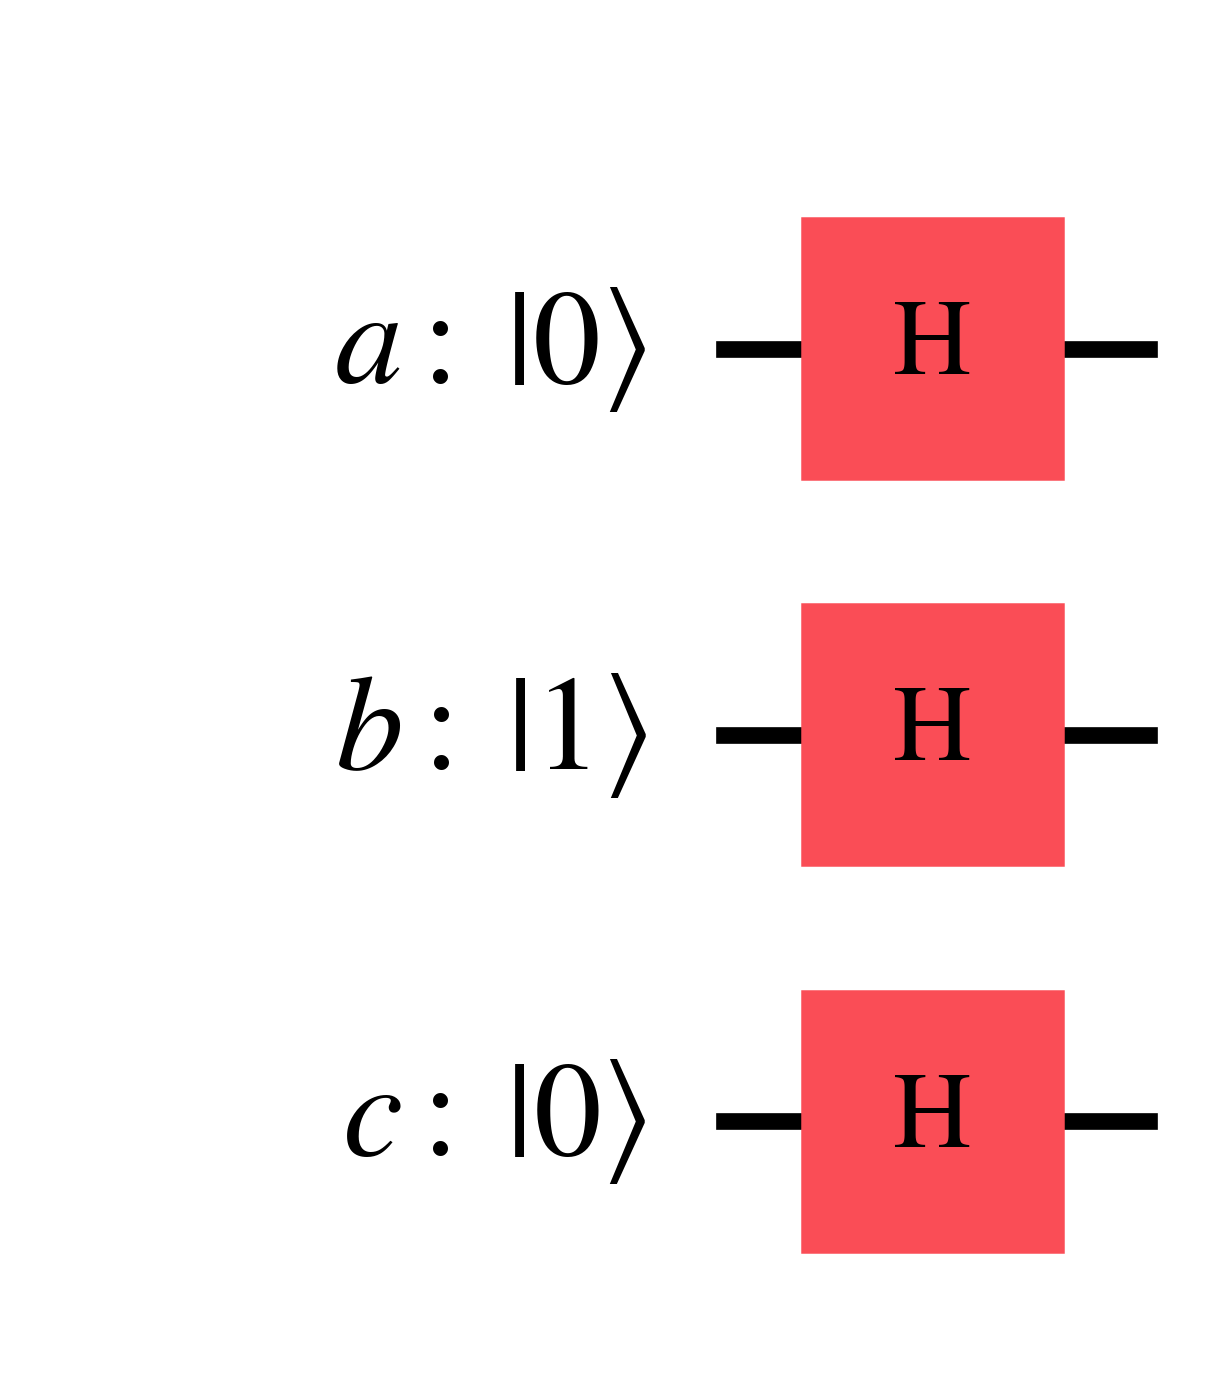

In [107]:
a= QuantumRegister(1, "a: |0⟩")
b= QuantumRegister(1, "b: |1⟩")
c= QuantumRegister(1, "c: |0⟩")
qc=QuantumCircuit(a,b,c)

qc.h(0)
qc.h(1)
qc.h(2)

fig_qc = qc.draw(output='mpl', scale =1.5)
fig_qc.savefig(figure_directory+'three_qubit_hadamard_transform', bbox_inches='tight')

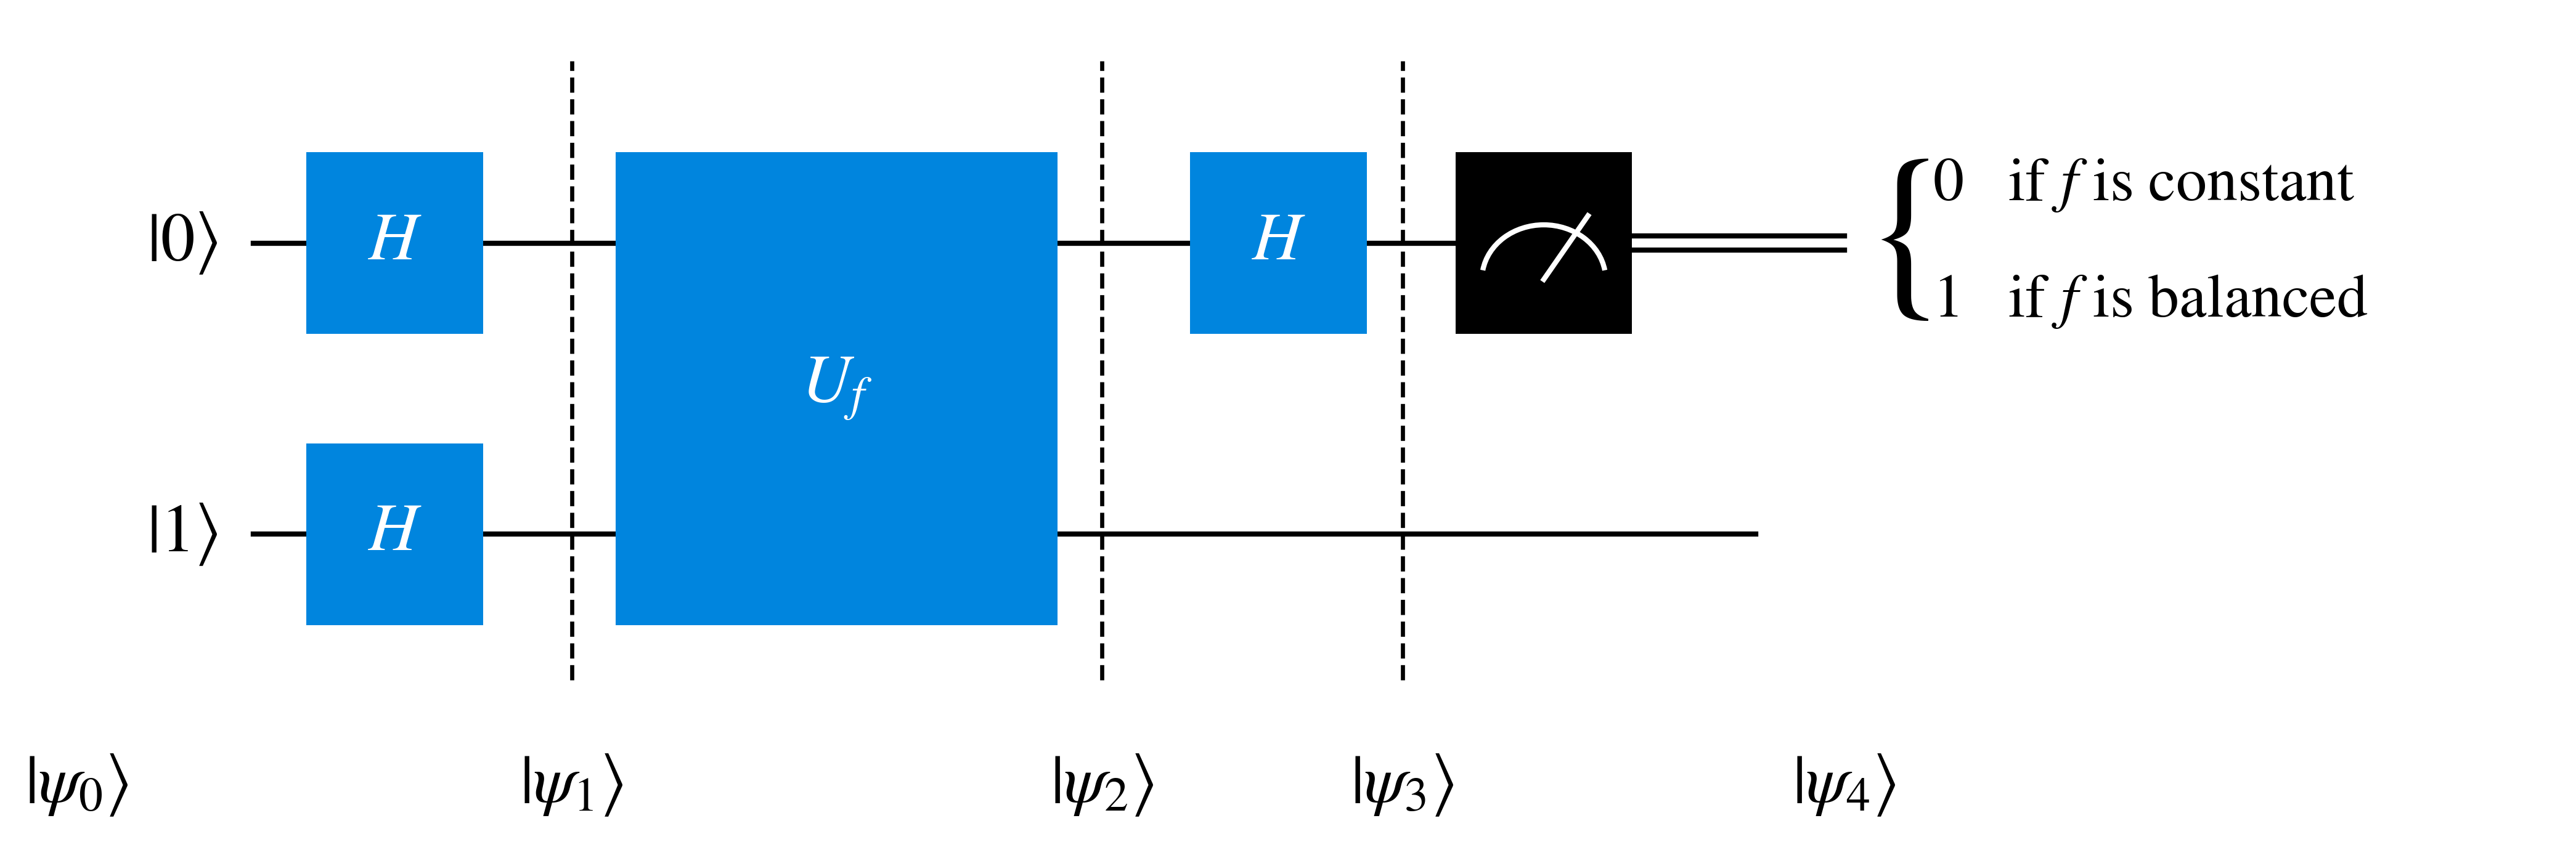

In [131]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_deutsch_circuit(filename="deutsch_algorithm_sketch.png"):
    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(11, 4))
    
    # Coordinate system limits
    ax.set_xlim(0, 1.4)
    ax.set_ylim(-0.1, 1.0)
    ax.axis('off')

    # Colors
    BLUE = '#0085DE'  # Close match to the blue in the image
    BLACK = 'black'

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def draw_gate(x, y, text, width=0.1, height=0.25):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=20, ha='center', va='center', zorder=4)

    def draw_meter(x, y, width=0.1, height=0.25):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y - height/5), width*0.7, height*0.6, theta1=20, theta2=160, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x + width*0.25], [y - height/5, y + height*0.15], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 1. WIRES & INITIAL STATES
    # ==========================================
    y_top = 0.7
    y_bottom = 0.3
    
    # Qubit lines
    ax.plot([0.1, 0.85], [y_top, y_top], color=BLACK, lw=1.5, zorder=1)
    ax.plot([0.1, 0.95], [y_bottom, y_bottom], color=BLACK, lw=1.5, zorder=1)

    # Initial States
    ax.text(0.08, y_top, r'$|0\rangle$', fontsize=20, ha='right', va='center')
    ax.text(0.08, y_bottom, r'$|1\rangle$', fontsize=20, ha='right', va='center')

    # ==========================================
    # 2. GATES
    # ==========================================
    # First layer H gates
    draw_gate(0.18, y_top, r'$H$')
    draw_gate(0.18, y_bottom, r'$H$')

    # Oracle U_f
    # Positioned between the wires, covering both
    draw_gate(0.43, 0.5, r'$U_f$', width=0.25, height=0.65)

    # Second layer H gate (Top wire only)
    draw_gate(0.68, y_top, r'$H$')

    # Measurement Meter
    draw_meter(0.83, y_top)

    # ==========================================
    # 3. CLASSICAL OUTPUT & BRACE
    # ==========================================
    # Double lines coming out of the meter
    gap = 0.02
    ax.plot([0.88, 1.0], [y_top + gap/2, y_top + gap/2], color=BLACK, lw=1.5)
    ax.plot([0.88, 1.0], [y_top - gap/2, y_top - gap/2], color=BLACK, lw=1.5)

    # Large curly brace and result text
    ax.text(1.01, y_top, r'$\{$', fontsize=55, va='center', ha='left')
    ax.text(1.05, y_top + 0.08, r'$0 \quad \mathrm{if} \ f \ \mathrm{is \ constant}$', fontsize=18, va='center', ha='left')
    ax.text(1.05, y_top - 0.08, r'$1 \quad \mathrm{if} \ f \ \mathrm{is \ balanced}$', fontsize=18, va='center', ha='left')

    # ==========================================
    # 4. DASHED LINES & PSI LABELS
    # ==========================================
    # X coordinates for the three vertical barriers
    barrier_xs = [0.28, 0.58, 0.75]
    
    ax.text(0, 0.0, fr'$|\psi_{0}\rangle$', fontsize=20, ha='center', va='top')
    ax.text(1, 0.0, fr'$|\psi_{4}\rangle$', fontsize=20, ha='center', va='top')
    for i, x_pos in enumerate(barrier_xs):
        # Draw dashed line
        ax.plot([x_pos, x_pos], [0.1, 0.95], color=BLACK, linestyle='--', lw=1.2, zorder=1)
        # Add requested \psi state label below
        ax.text(x_pos, 0.0, fr'$|\psi_{i+1}\rangle$', fontsize=20, ha='center', va='top')

    # Save and show
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Run the function
draw_deutsch_circuit()

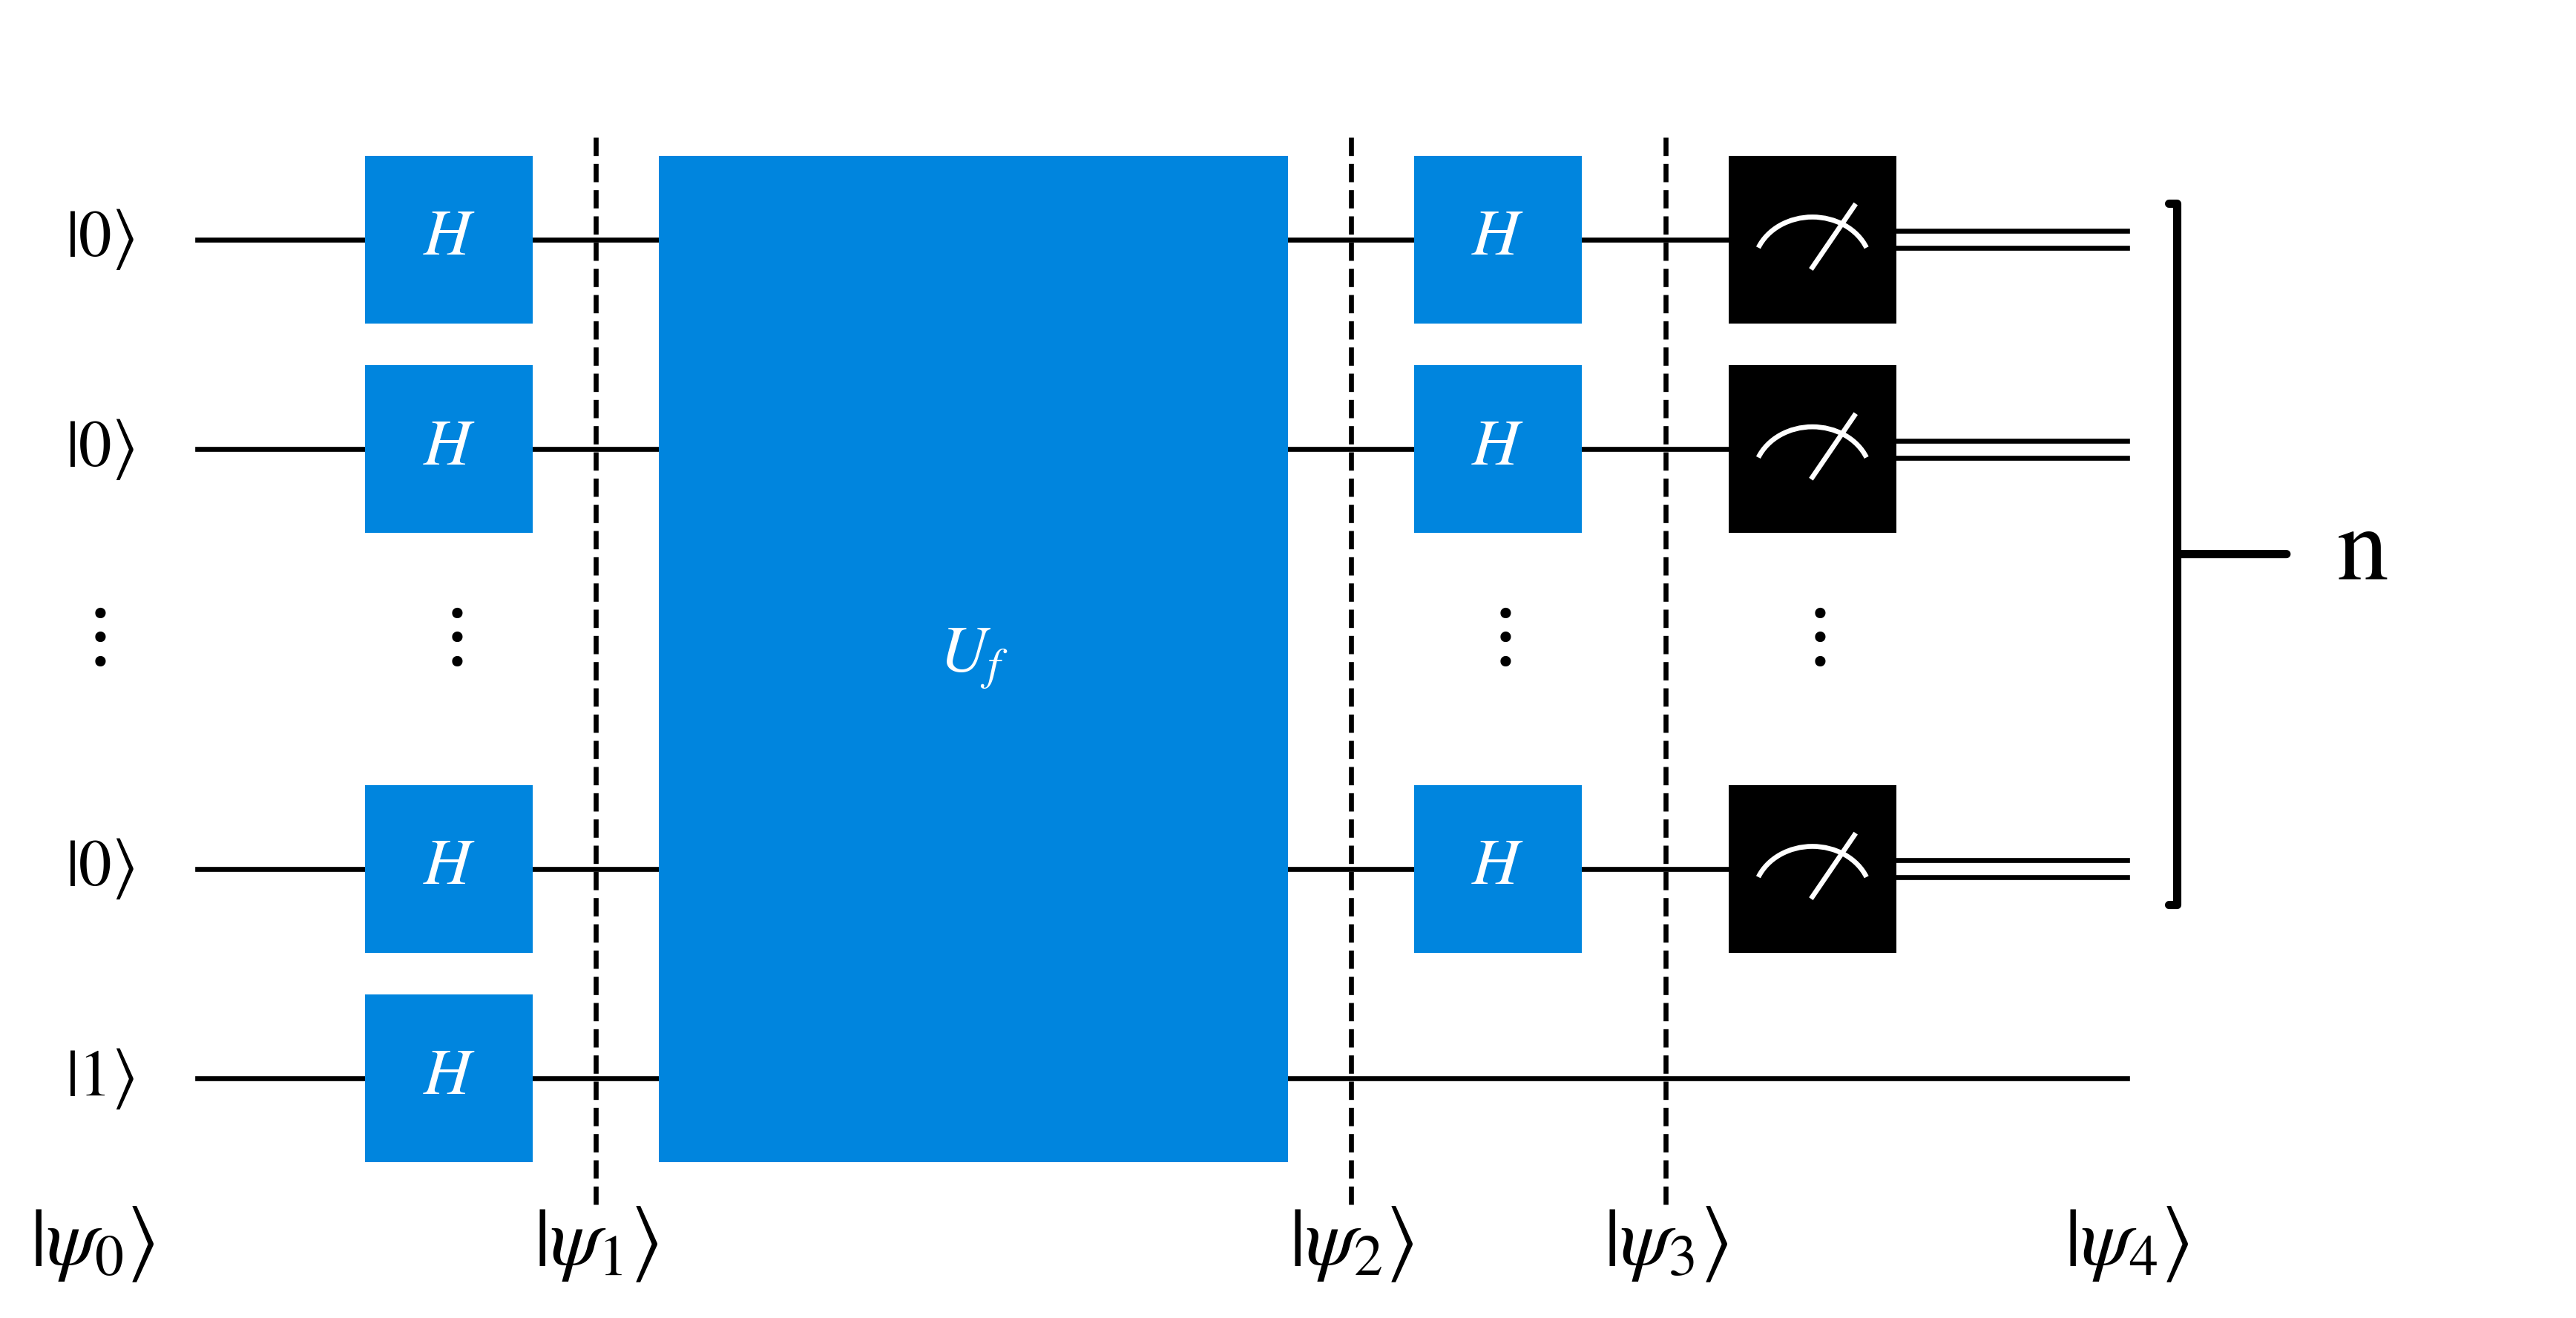

In [138]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_n_qubit_circuit(filename="n_qubit_algorithm.png"):
    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Coordinate system limits
    ax.set_xlim(0, 12)
    ax.set_ylim(-1, 5)
    ax.axis('off')
    ax.set_aspect('equal') # Keeps gates perfectly square

    # Colors
    BLUE = '#0085DE'  # Close match to the blue in the image
    BLACK = 'black'

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def draw_gate(x, y, text, w=0.8, h=0.8, color=BLUE):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=16, ha='center', va='center', zorder=4)

    def draw_meter(x, y, w=0.8, h=0.8):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y - h/6), w*0.7, h*0.6, theta1=20, theta2=160, color='white', lw=1.2, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x + w*0.25], [y - h/6, y + h*0.2], color='white', lw=1.2, zorder=4)

    def draw_double_line(x_start, x_end, y, gap=0.08):
        ax.plot([x_start, x_end], [y + gap/2, y + gap/2], color=BLACK, lw=1.2, zorder=1)
        ax.plot([x_start, x_end], [y - gap/2, y - gap/2], color=BLACK, lw=1.2, zorder=1)

    # ==========================================
    # 1. WIRES & INITIAL STATES
    # ==========================================
    y_top_wires = [4, 3, 1]
    y_bottom_wire = 0
    y_dots = 2

    x_start_labels = 0.5
    x_wire_start = 0.8
    x_H1 = 2.0
    x_Uf = 4.5
    x_H2 = 7.0
    x_meter = 8.5
    x_wire_end = 10.0

    # Draw solid lines
    for y in y_top_wires:
        ax.plot([x_wire_start, x_meter], [y, y], color=BLACK, lw=1.2, zorder=1)
        draw_double_line(x_meter, x_wire_end, y)
        ax.text(x_start_labels, y, r'$|0\rangle$', fontsize=16, ha='right', va='center')

    # Bottom wire
    ax.plot([x_wire_start, x_wire_end], [y_bottom_wire, y_bottom_wire], color=BLACK, lw=1.2, zorder=1)
    ax.text(x_start_labels, y_bottom_wire, r'$|1\rangle$', fontsize=16, ha='right', va='center')

    # ==========================================
    # 2. GATES
    # ==========================================
    # First layer H gates (applies to all wires)
    for y in y_top_wires + [y_bottom_wire]:
        draw_gate(x_H1, y, r'$H$')

    # Oracle U_f block (spanning all wires)
    draw_gate(x_Uf, 2, r'$U_f$', w=3.0, h=4.8)

    # Second layer H gates and Meters (applies to top wires only)
    for y in y_top_wires:
        draw_gate(x_H2, y, r'$H$')
        draw_meter(x_meter, y)

    # ==========================================
    # 3. ELLIPSES (Dots)
    # ==========================================
    # Place vertical ellipses to represent the n-qubits
    dot_x_positions = [x_start_labels - 0.2, x_H1, x_H2, x_meter]
    for x in dot_x_positions:
        ax.text(x, y_dots + 0.1, r'$\vdots$', fontsize=20, ha='center', va='center')

    # ==========================================
    # 4. CURLY BRACE & OUTPUT TEXT
    # ==========================================
    # Using a large font size for the curly brace
    #ax.text(10.1, 2.5, r'$\}$', fontsize=85, color='black', va='center', ha='left')
    bracket_arrow_style = patches.ArrowStyle.BracketB(widthB=85.0, lengthB=2, angleB=0)
    arrow = patches.FancyArrowPatch(posA=(10.8, 2.5),posB=(10.2, 2.5), arrowstyle=bracket_arrow_style, linewidth=2, color='black')
    ax.add_patch(arrow)
    ax.text(11, 2.5, r'n', fontsize=25, va='center', ha='left')



        # X coordinates for the three vertical barriers
    barrier_xs = [2.7, 6.3, 7.8]
    
    ax.text(0.3, -0.6, fr'$|\psi_{0}\rangle$', fontsize=20, ha='center', va='top')
    ax.text(10, -0.6, fr'$|\psi_{4}\rangle$', fontsize=20, ha='center', va='top')
    for i, x_pos in enumerate(barrier_xs):
        # Draw dashed line
        ax.plot([x_pos, x_pos], [-0.6, 4.5], color=BLACK, linestyle='--', lw=1.2, zorder=1)
        # Add requested \psi state label below
        ax.text(x_pos, -0.6, fr'$|\psi_{i+1}\rangle$', fontsize=20, ha='center', va='top')

    # Save and display
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Execute the drawing function
draw_n_qubit_circuit('deutsch_jozsa_algorithm_sketch.png')